# Confidence Interval

We'll see how to use **Bootstrapping** to calculate the **95% Confidence Interval**.

Data scientists would use this information:

1. to communicate the potential error in an estimate
2. to learn whether a larger sample is needed

In [1]:
import pandas as pd

## Bootstrapping

In modern statistics, the bootstrap has become the standard way to estimate standard error:

1. it can be used for virtually any statistic and
2. does not rely on any distributional assumptions (such as data being normally distributed)

The core engine `utils.bootstraps` takes any `statistic` callable and returns:

1. point estimate (mean of the bootstrap statistics)
2. standard error `se`
3. confidence interval `(ci_lower, ci_upper)` (default confidence level is 95%)

Three thin wrappers pick the statistic for you:

- `bootstraps_mean` — for the population **mean**
- `bootstraps_std` — for the population **standard deviation** (`ddof=1`)
- `bootstraps_proportion` — for a population **proportion** (binary 0/1 data)

In [2]:
from utils import bootstraps_mean, bootstraps_std, bootstraps_proportion

For reference see [scipy.stats.bootstrap](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bootstrap.html) and it's [source code](https://github.com/scipy/scipy/blob/cadff2794c526d283f0c048e3c19d8b960d9e415/scipy/stats/_resampling.py#L300) implementation.

## Estimate Mean

We begin with the most familiar statistic: the **mean** of a numerical variable.
The wrapper `bootstraps_mean` plugs `np.mean` into the generic bootstrap loop.

### Apply on adults `hours-per-week` numerical value

In [3]:
from pathlib import Path

data_path = Path('../data/adult.csv')
data_path.exists()

True

In [4]:
df_raw = pd.read_csv(data_path)
df = df_raw[['hours-per-week', 'age']]
df

,hours-per-week,age
0,40,39
1,13,50
2,40,38
3,40,53
4,40,28
...,...,...
32556,38,27
32557,40,40
32558,40,58
32559,20,22


Set `trace=True` to see how the procedure executes

In [5]:
mean, se, ci = bootstraps_mean(
    df['hours-per-week'],
    n_resamples=1000,
    confidence_level=95,
    trace=True
)

Bootstrapping 1000 samples...
The 0-th sample of size 30 is bootstrapped...
The 10-th sample of size 30 is bootstrapped...
The 20-th sample of size 30 is bootstrapped...
The 30-th sample of size 30 is bootstrapped...
The 40-th sample of size 30 is bootstrapped...
The 50-th sample of size 30 is bootstrapped...
The 60-th sample of size 30 is bootstrapped...
The 70-th sample of size 30 is bootstrapped...
The 80-th sample of size 30 is bootstrapped...
The 90-th sample of size 30 is bootstrapped...
The 100-th sample of size 30 is bootstrapped...
The 110-th sample of size 30 is bootstrapped...
The 120-th sample of size 30 is bootstrapped...
The 130-th sample of size 30 is bootstrapped...
The 140-th sample of size 30 is bootstrapped...
The 150-th sample of size 30 is bootstrapped...
The 160-th sample of size 30 is bootstrapped...
The 170-th sample of size 30 is bootstrapped...
The 180-th sample of size 30 is bootstrapped...
The 190-th sample of size 30 is bootstrapped...
The 200-th sample of 

In [6]:
print("For hours per week:-")
print(f"Sampling Distribution Mean  = {mean:.1f}")
print(f"Standard Error              = {se:.1f}")
print(f"The 95% Confidence Interval = ({ci[0]:.1f}, {ci[1]:.1f})")

For hours per week:-
Sampling Distribution Mean  = 40.5
Standard Error              = 2.3
The 95% Confidence Interval = (36.0, 45.2)


Thus the probability that the population average `hours-per-week` lies between (36.2, 45.0) is: 95%.

In mathematical terms:

$$ P(\mu_\text{hours-per-week} \in (36.2, 45.0)) = 0.95 $$

### Apply on adults `age`

In [7]:
mean, se, ci, bootstrap_means = bootstraps_mean(
    df['age'],
    n_resamples=999,
    confidence_level=95,
    return_bootstrap_stats=True,
)

In [8]:
print("For age:-")
print(f"Sampling Distribution Mean  = {mean:.1f}")
print(f"Standard Error              = {se:.1f}")
print(f"The 95% Confidence Interval = ({ci[0]:.1f}, {ci[1]:.1f})")

For age:-
Sampling Distribution Mean  = 38.6
Standard Error              = 2.5
The 95% Confidence Interval = (33.9, 43.2)


Thus the probability that the population average `age` lies between (33.4, 43.3) is: 95%.

In mathematical terms:

$$ P(\mu_\text{age} \in (33.4, 43.3)) = 0.95 $$

#### Visualize Sampling Distribution

- Left: distribution of the variable (`age`) itself, with the sample mean drawn as a dashed line
- Right: distribution of the statistic (`mean_age`) for `n_resamples=999`, with the 95% CI shaded

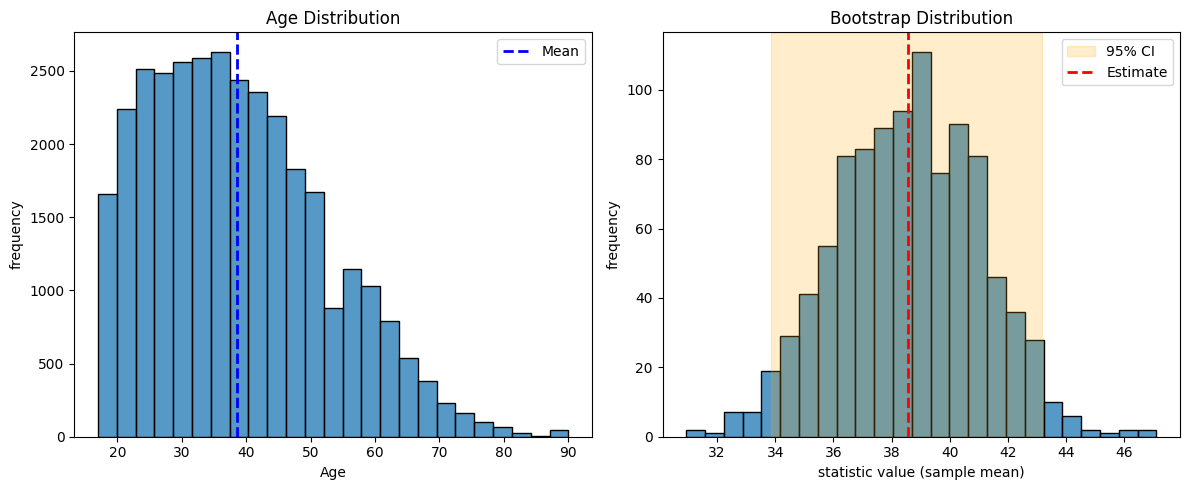

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left panel: age distribution with the sample mean marked
sns.histplot(df['age'], bins=25, ax=axes[0])
axes[0].axvline(df['age'].mean(), color='blue', linestyle='dashed', linewidth=2, label='Mean')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('frequency')
axes[0].legend()

# Right panel: bootstrap sampling distribution of the mean + 95% CI shading
sns.histplot(bootstrap_means, bins=25, ax=axes[1])
axes[1].axvspan(ci[0], ci[1], alpha=0.2, color='orange', label='95% CI')
axes[1].axvline(mean, color='red', linestyle='dashed', linewidth=2, label='Estimate')
axes[1].set_title('Bootstrap Distribution')
axes[1].set_xlabel('statistic value (sample mean)')
axes[1].set_ylabel('frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

### Standard Deviation vs. Versus Standard Error

Do not confuse standard deviation (which measures the variability of individual data points) with standard error (which measures the variability of a sample metric).

In [10]:
print(f"Standard Deviation is about age variable (left): {df['age'].std():0.2f}")
print(f"Standard Error is about mean_age statistic (right): {se:0.2f}")

Standard Deviation is about age variable (left): 13.64
Standard Error is about mean_age statistic (right): 2.48


## Estimate Standard Deviation

The bootstrap also works for **spread**, not just central tendency.

- Same algorithm, different `statistic`.
- The wrapper `bootstraps_std` plugs `np.std(..., ddof=1)` into the generic bootstrap loop.
- The resulting CI tells us where the **population standard deviation** likely sits, given our sample.

### Apply on adults `age`

In [11]:
std, se, ci, bootstrap_stds = bootstraps_std(
    df['age'],
    n_resamples=999,
    confidence_level=95,
    return_bootstrap_stats=True,
)

In [12]:
print("For age (standard deviation):-")
print(f"Sampling Distribution Mean  = {std:.2f}")
print(f"Standard Error              = {se:.2f}")
print(f"The 95% Confidence Interval = ({ci[0]:.2f}, {ci[1]:.2f})")

For age (standard deviation):-
Sampling Distribution Mean  = 13.51
Standard Error              = 1.64
The 95% Confidence Interval = (10.46, 16.86)


Thus the probability that the population standard deviation of `age` lies between (10.27, 17.22) is: 95%.

In mathematical terms:

$$ P(\sigma_\text{age} \in (10.27, 17.22)) = 0.95 $$

#### Visualize Sampling Distribution

- Left: distribution of the variable (`age`) itself, with the sample standard deviation drawn as a span around the mean
- Right: distribution of the statistic (`std_age`) for `n_resamples=999`, with the 95% CI shaded

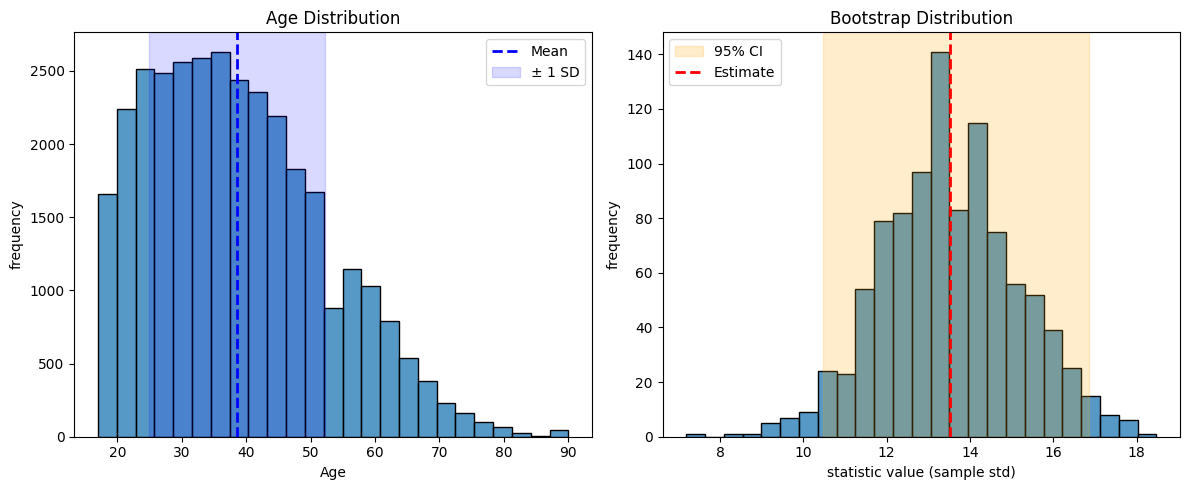

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Sample std and mean used as reference markers on the original data
sample_mean = df['age'].mean()
sample_std = df['age'].std(ddof=1)

# Left panel: age distribution + mean ± 1 std band
sns.histplot(df['age'], bins=25, ax=axes[0])
axes[0].axvline(sample_mean, color='blue', linestyle='dashed', linewidth=2, label='Mean')
axes[0].axvspan(sample_mean - sample_std, sample_mean + sample_std,
                alpha=0.15, color='blue', label='± 1 SD')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('frequency')
axes[0].legend()

# Right panel: bootstrap sampling distribution of the std + 95% CI shading
sns.histplot(bootstrap_stds, bins=25, ax=axes[1])
axes[1].axvspan(ci[0], ci[1], alpha=0.2, color='orange', label='95% CI')
axes[1].axvline(std, color='red', linestyle='dashed', linewidth=2, label='Estimate')
axes[1].set_title('Bootstrap Distribution')
axes[1].set_xlabel('statistic value (sample std)')
axes[1].set_ylabel('frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

## Estimate Proportion

For **categorical** outcomes we often care about a proportion — what fraction of the population falls in a given class.

- The trick: encode the category as a binary indicator (`0` / `1`) so that its **mean equals the proportion**.
- The wrapper `bootstraps_proportion` plugs `np.mean` into the generic bootstrap loop, but takes a binary vector.
- The resulting CI tells us where the **population proportion** likely sits, given our sample.

### Apply on adults `income > 50K`

We re-load the raw dataframe to get the `income` column, then turn the two
categories (`<=50K`, `>50K`) into a binary indicator `is_high_income`.

In [14]:
is_high_income = (df_raw['income'] == '>50K').astype(int)
is_high_income.value_counts(normalize=True)

income
0    0.75919
1    0.24081
Name: proportion, dtype: float64

In [15]:
prop, se, ci, bootstrap_props = bootstraps_proportion(
    is_high_income,
    n_resamples=999,
    confidence_level=95,
    return_bootstrap_stats=True,
)

In [16]:
print("For income > 50K (proportion):-")
print(f"Sampling Distribution Mean  = {prop:.3f}")
print(f"Standard Error              = {se:.3f}")
print(f"The 95% Confidence Interval = ({ci[0]:.3f}, {ci[1]:.3f})")

For income > 50K (proportion):-
Sampling Distribution Mean  = 0.240
Standard Error              = 0.078
The 95% Confidence Interval = (0.100, 0.400)


Thus the probability that the population proportion of adults with `income > 50K` lies between (0.100, 0.400) is: 95%.

In mathematical terms:

$$ P(p_\text{income>50K} \in (0.100, 0.400)) = 0.95 $$

#### Visualize Sampling Distribution

- Left: distribution of the binary indicator itself — just two bars (`<=50K` vs `>50K`) showing the observed proportions
- Right: distribution of the statistic (sample proportion) for `n_resamples=999`, with the 95% CI shaded

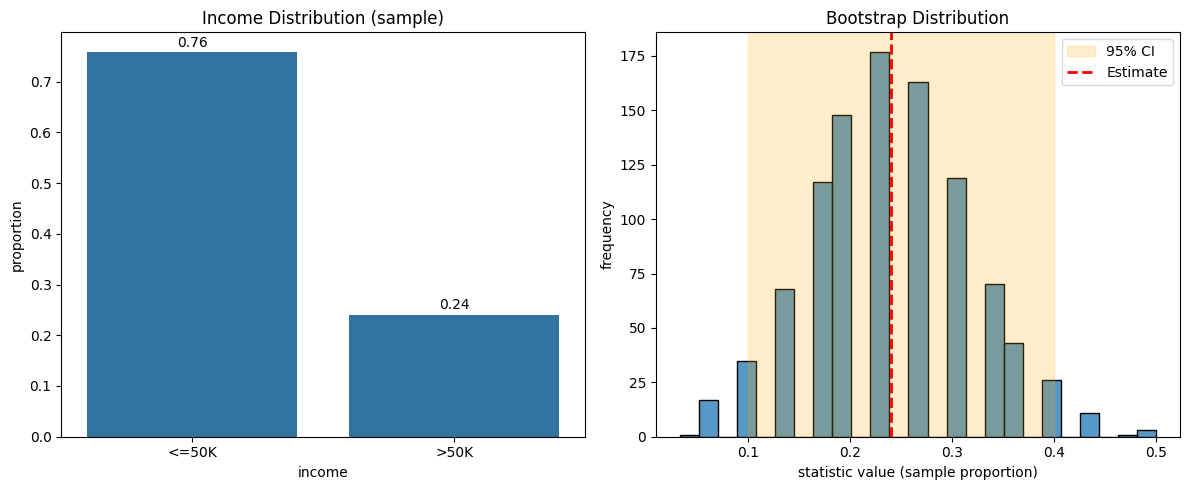

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left panel: observed proportions of the binary indicator
income_counts = is_high_income.value_counts(normalize=True).rename({0: '<=50K', 1: '>50K'})
sns.barplot(
    x=income_counts.index,
    y=income_counts.values,
    ax=axes[0],
)
axes[0].set_title('Income Distribution (sample)')
axes[0].set_xlabel('income')
axes[0].set_ylabel('proportion')
for i, v in enumerate(income_counts.values):
    axes[0].text(i, v + 0.01, f'{v:.2f}', ha='center')

# Right panel: bootstrap sampling distribution of the proportion + 95% CI shading
sns.histplot(bootstrap_props, bins=25, ax=axes[1])
axes[1].axvspan(ci[0], ci[1], alpha=0.2, color='orange', label='95% CI')
axes[1].axvline(prop, color='red', linestyle='dashed', linewidth=2, label='Estimate')
axes[1].set_title('Bootstrap Distribution')
axes[1].set_xlabel('statistic value (sample proportion)')
axes[1].set_ylabel('frequency')
axes[1].legend()

plt.tight_layout()
plt.show()